In [1]:
"Pormpt: give code of this question"
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as F
from torchvision.utils import draw_bounding_boxes
import random
from skimage import measure
from skimage.measure import regionprops


# Define paths
train_image_dir = "./Datasets/Q2/detection/train/images"
train_mask_dir = "./Datasets/Q2/detection/train/masks"

# 3.1.1 Load the dataset and process masks to extract bounding box coordinates
def load_dataset(image_dir, mask_dir):
    """
    Load images and masks, and organize them into a dataset structure
    """
    dataset = []
    
    # Get list of image files
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')])
    
    for img_file in image_files:
        # Construct corresponding mask filename
        mask_file = img_file  # Same name as per the description
        
        # Check if mask file exists
        if not os.path.exists(os.path.join(mask_dir, mask_file)):
            print(f"Warning: Mask file {mask_file} not found for image {img_file}")
            continue
        
        # Add to dataset
        dataset.append({
            'image_path': os.path.join(image_dir, img_file),
            'mask_path': os.path.join(mask_dir, mask_file),
            'id': img_file.split('.')[0]
        })

    
    print(f"Loaded {len(dataset)} image-mask pairs")
    return dataset

dataset = load_dataset(train_image_dir, train_mask_dir)
print(dataset[0])

Loaded 670 image-mask pairs
{'image_path': './Datasets/Q2/detection/train/images/20150919_174151_image1.png', 'mask_path': './Datasets/Q2/detection/train/masks/20150919_174151_image1.png', 'id': '20150919_174151_image1'}


In [2]:
# 3.1.2 Create a function to convert segmentation masks to bounding box annotations
def masks_to_boxes(mask):
    """
    Convert segmentation mask to bounding boxes
    
    Args:
        mask: numpy array of the mask image (H, W)
    
    Returns:
        boxes: numpy array of bounding boxes in format [x_min, y_min, x_max, y_max]
    """
    # Make sure mask is a numpy array
    if not isinstance(mask, np.ndarray):
        mask = np.array(mask)
    
    # Convert RGB to grayscale if needed
    if len(mask.shape) == 3 and mask.shape[2] == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)
    
    # Use connected components to find instances in the mask
    labeled_mask = measure.label(mask > 0)
    
    # Get regions properties
    regions = regionprops(labeled_mask)
    
    boxes = []
    for region in regions:
        # Get bounding box coordinates
        y_min, x_min, y_max, x_max = region.bbox
        
        # Add bounding box to the list
        # Ensure boxes are not degenerate (have positive width and height)
        if x_max > x_min and y_max > y_min:
            boxes.append([x_min, y_min, x_max, y_max])
    
    # Handle case when no regions are found
    if not boxes:
        return np.zeros((0, 4), dtype=np.float32)
    
    return np.array(boxes)



### 3.1.3 Implement visualization functions to display

Processing example: 20150921_131833_image311


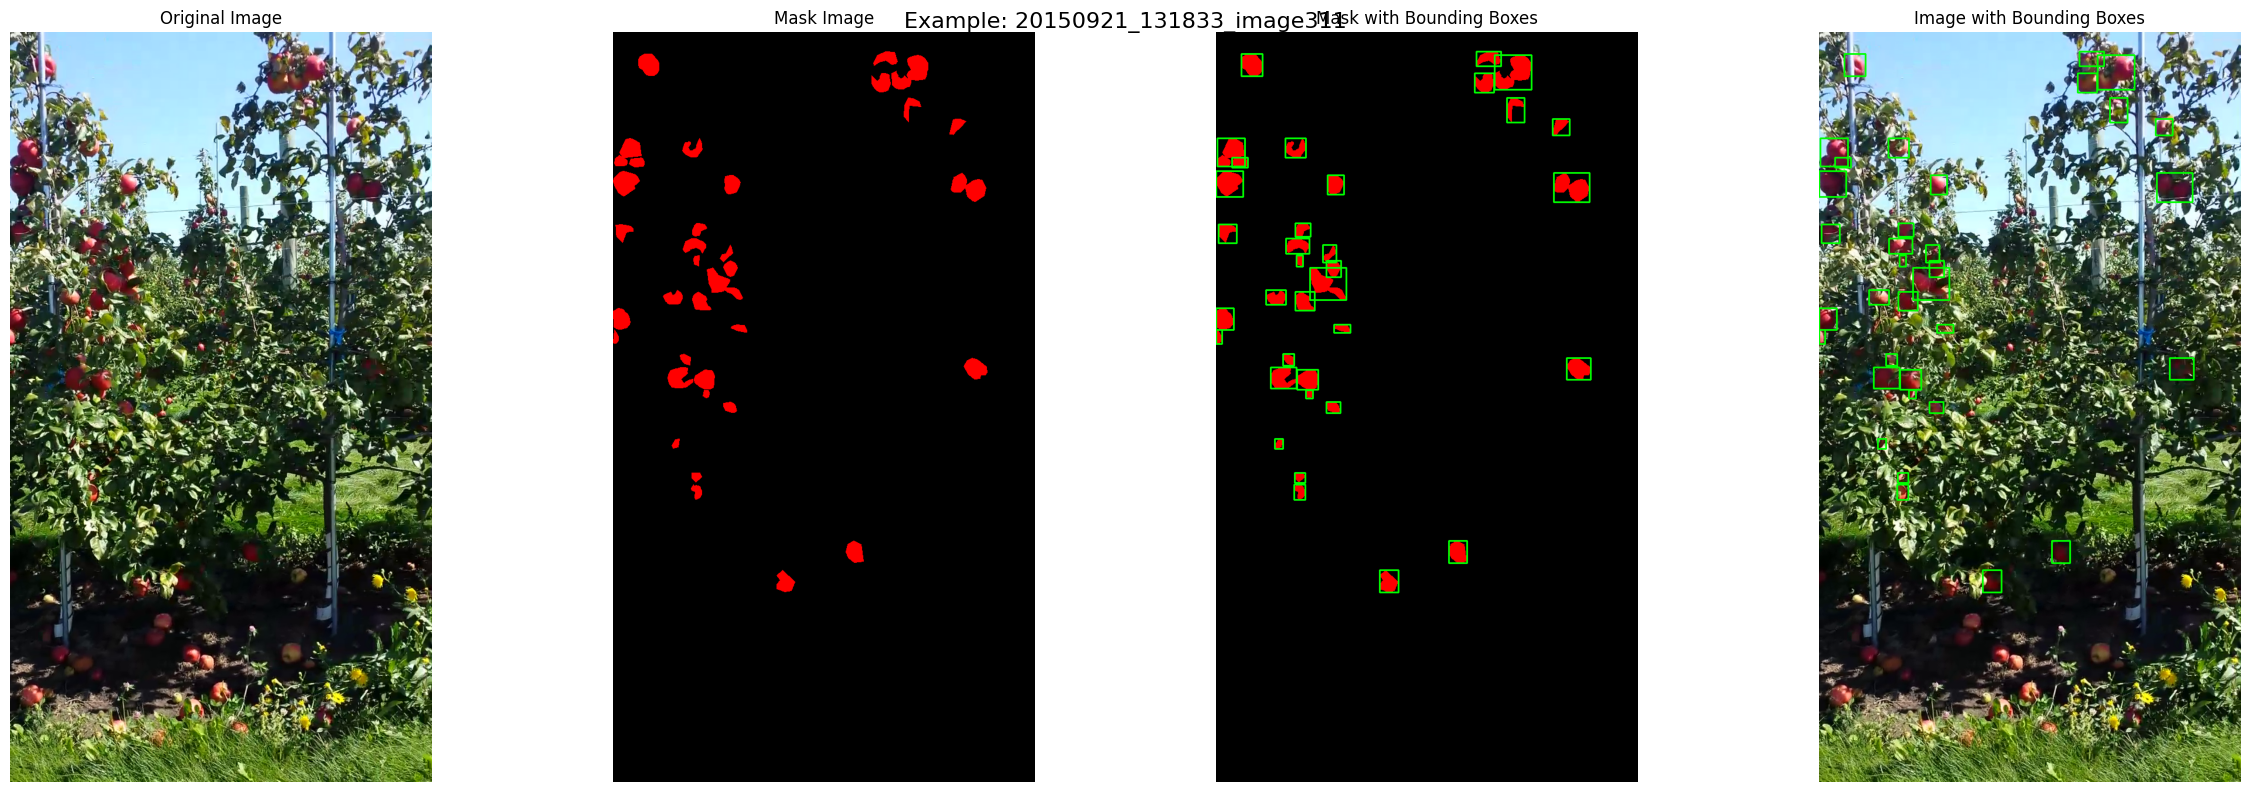

Processing example: 20150921_132038_image36


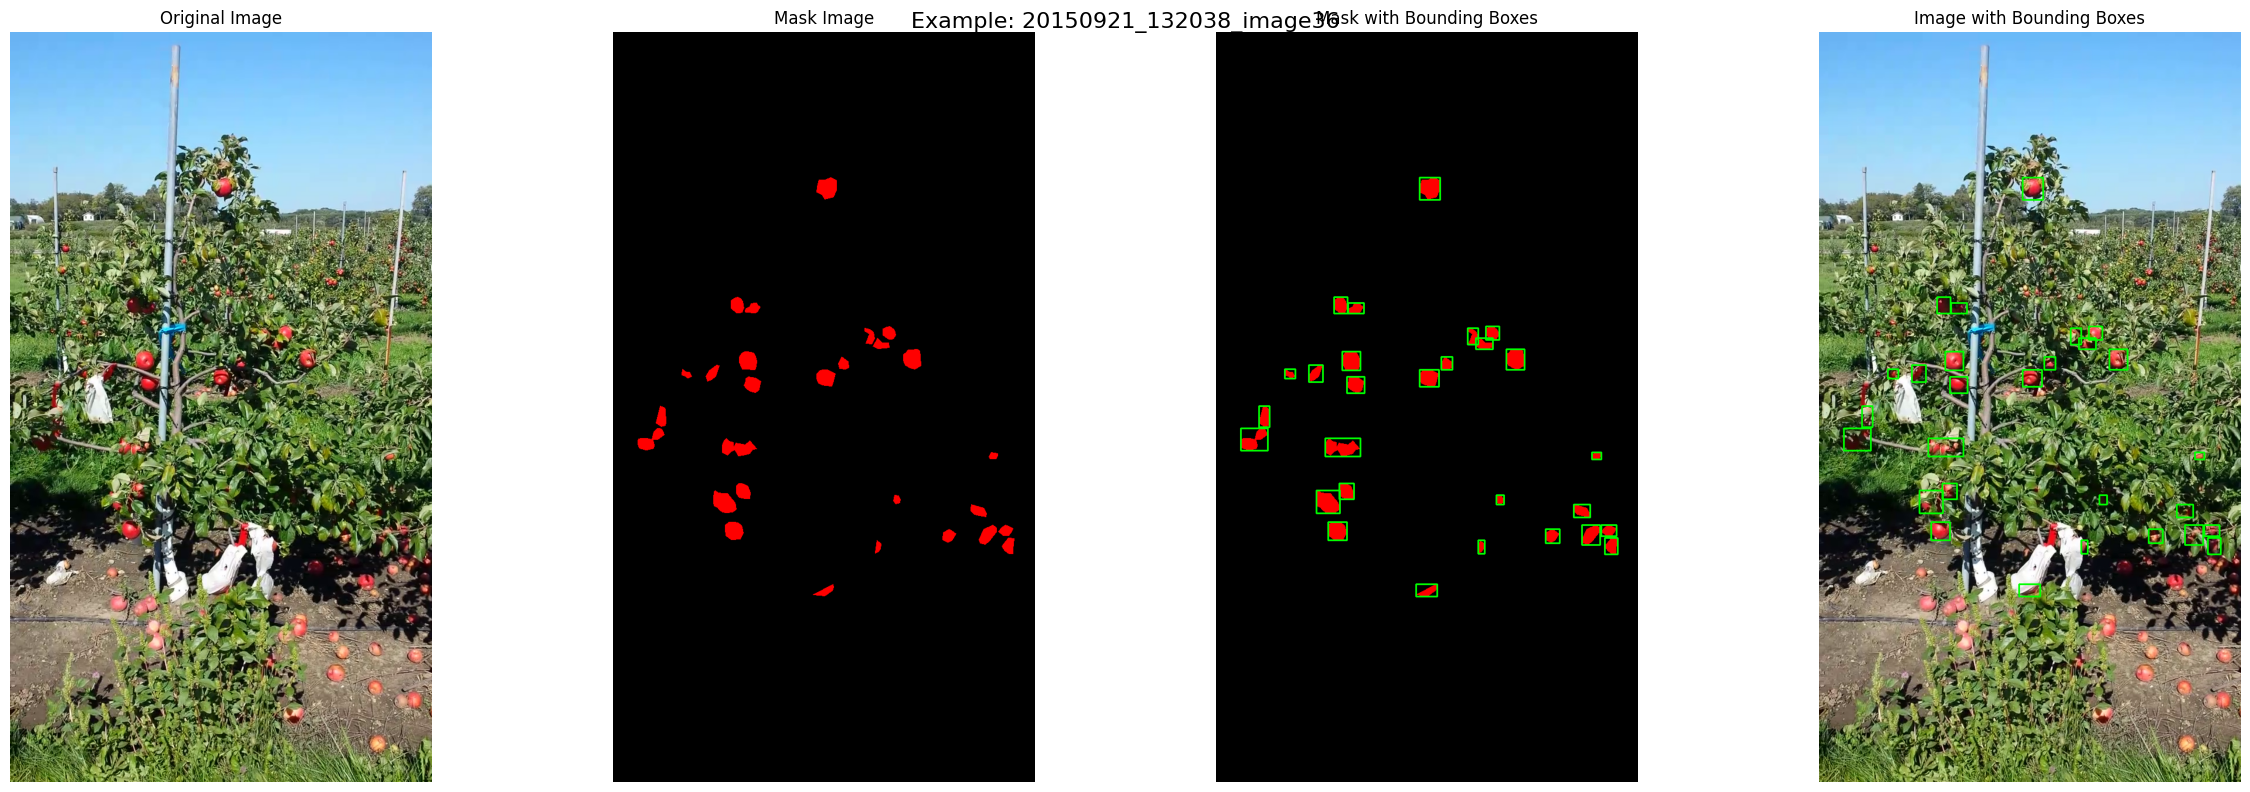

Processing example: 20150921_131453_image16


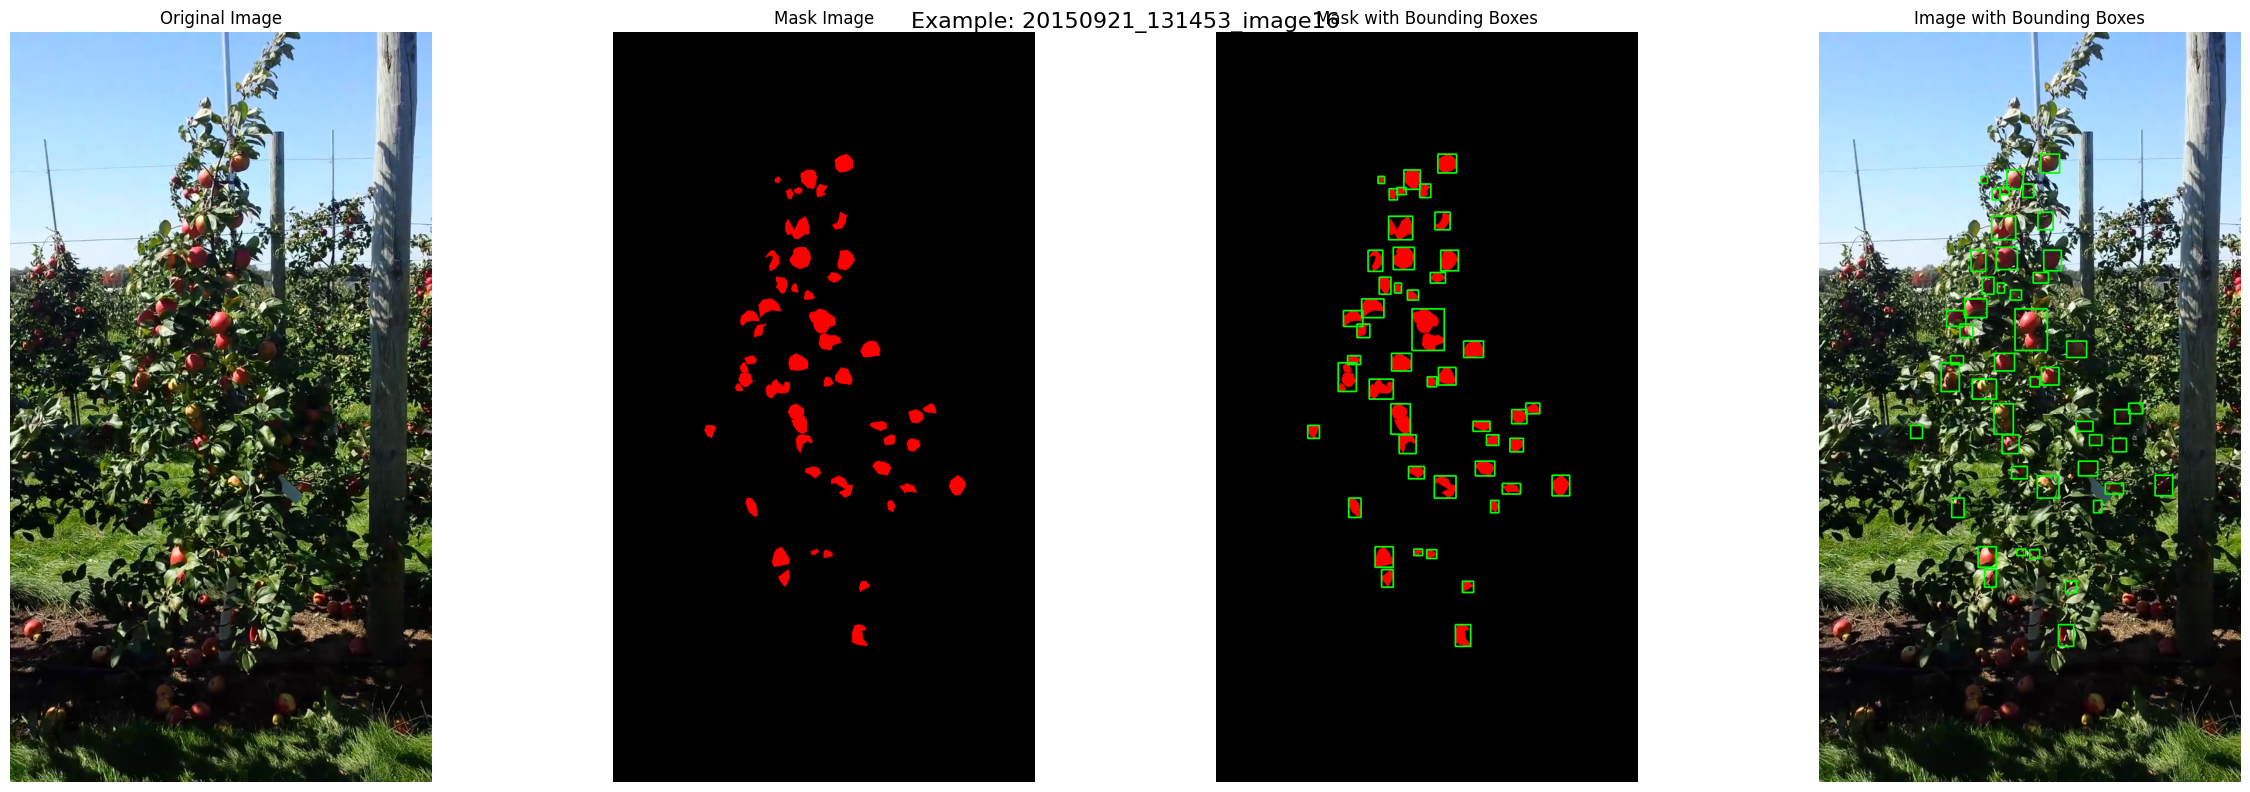

Processing example: 20150921_131453_image1121


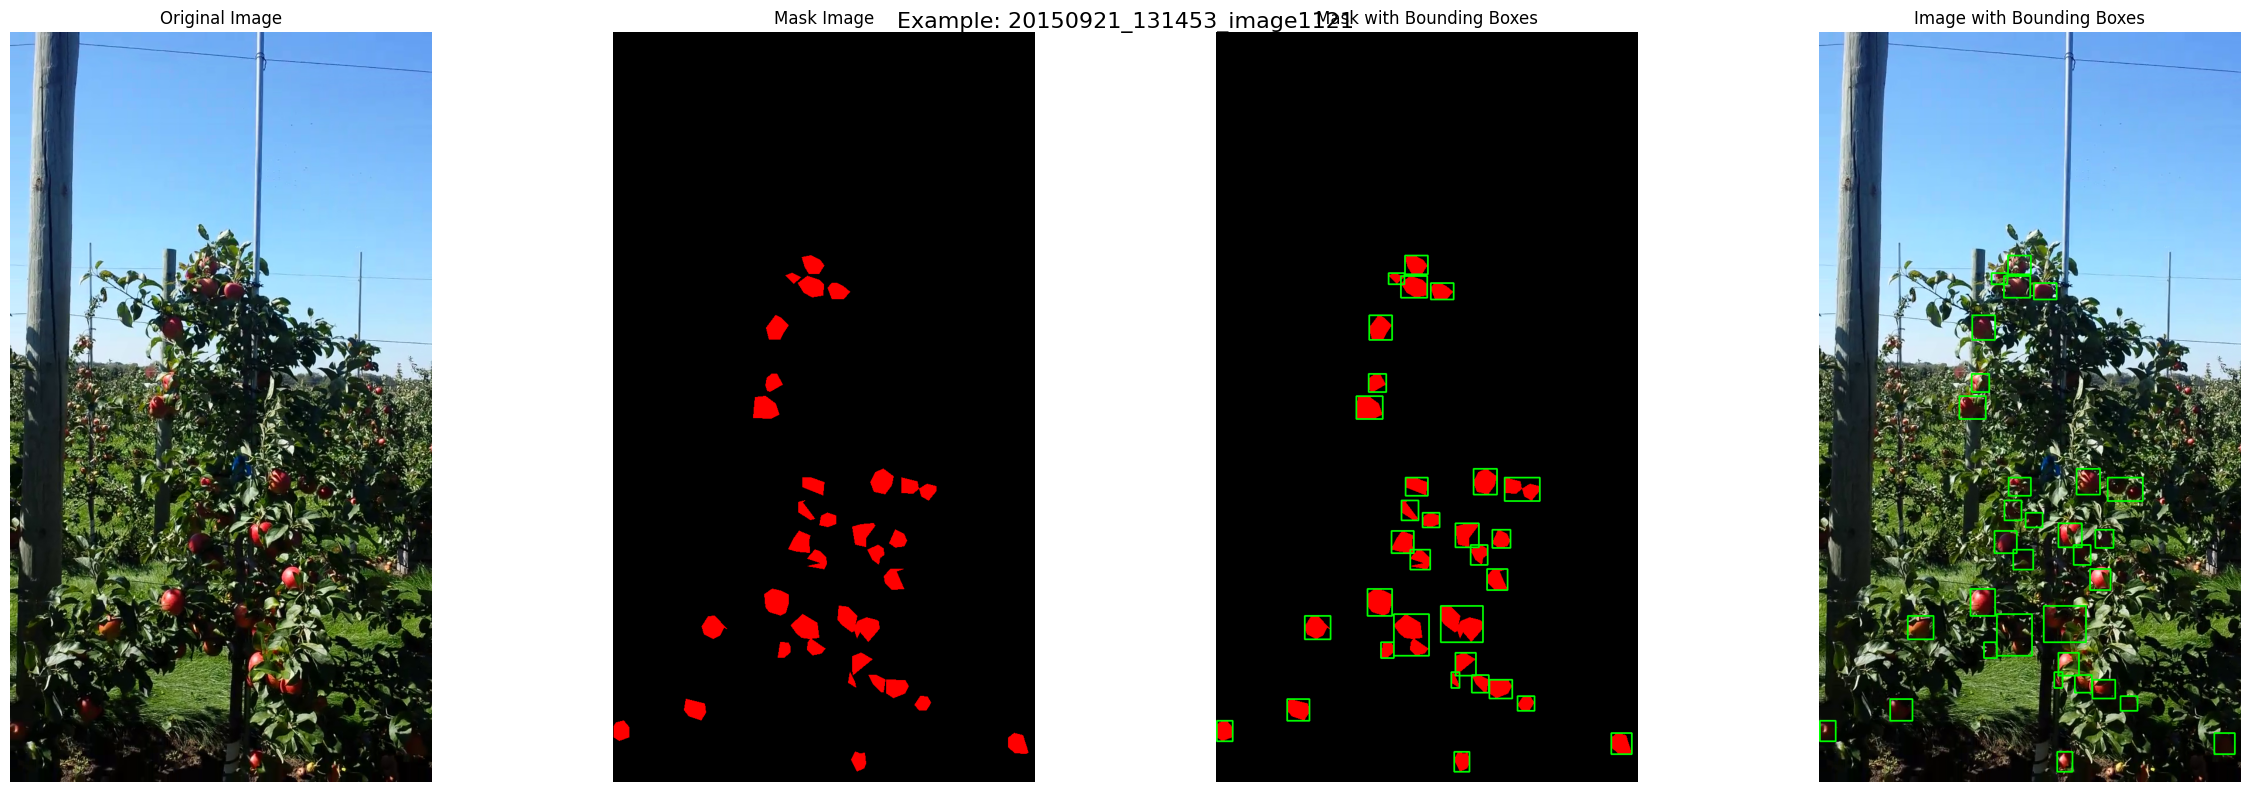

Processing example: 20150921_132038_image1006


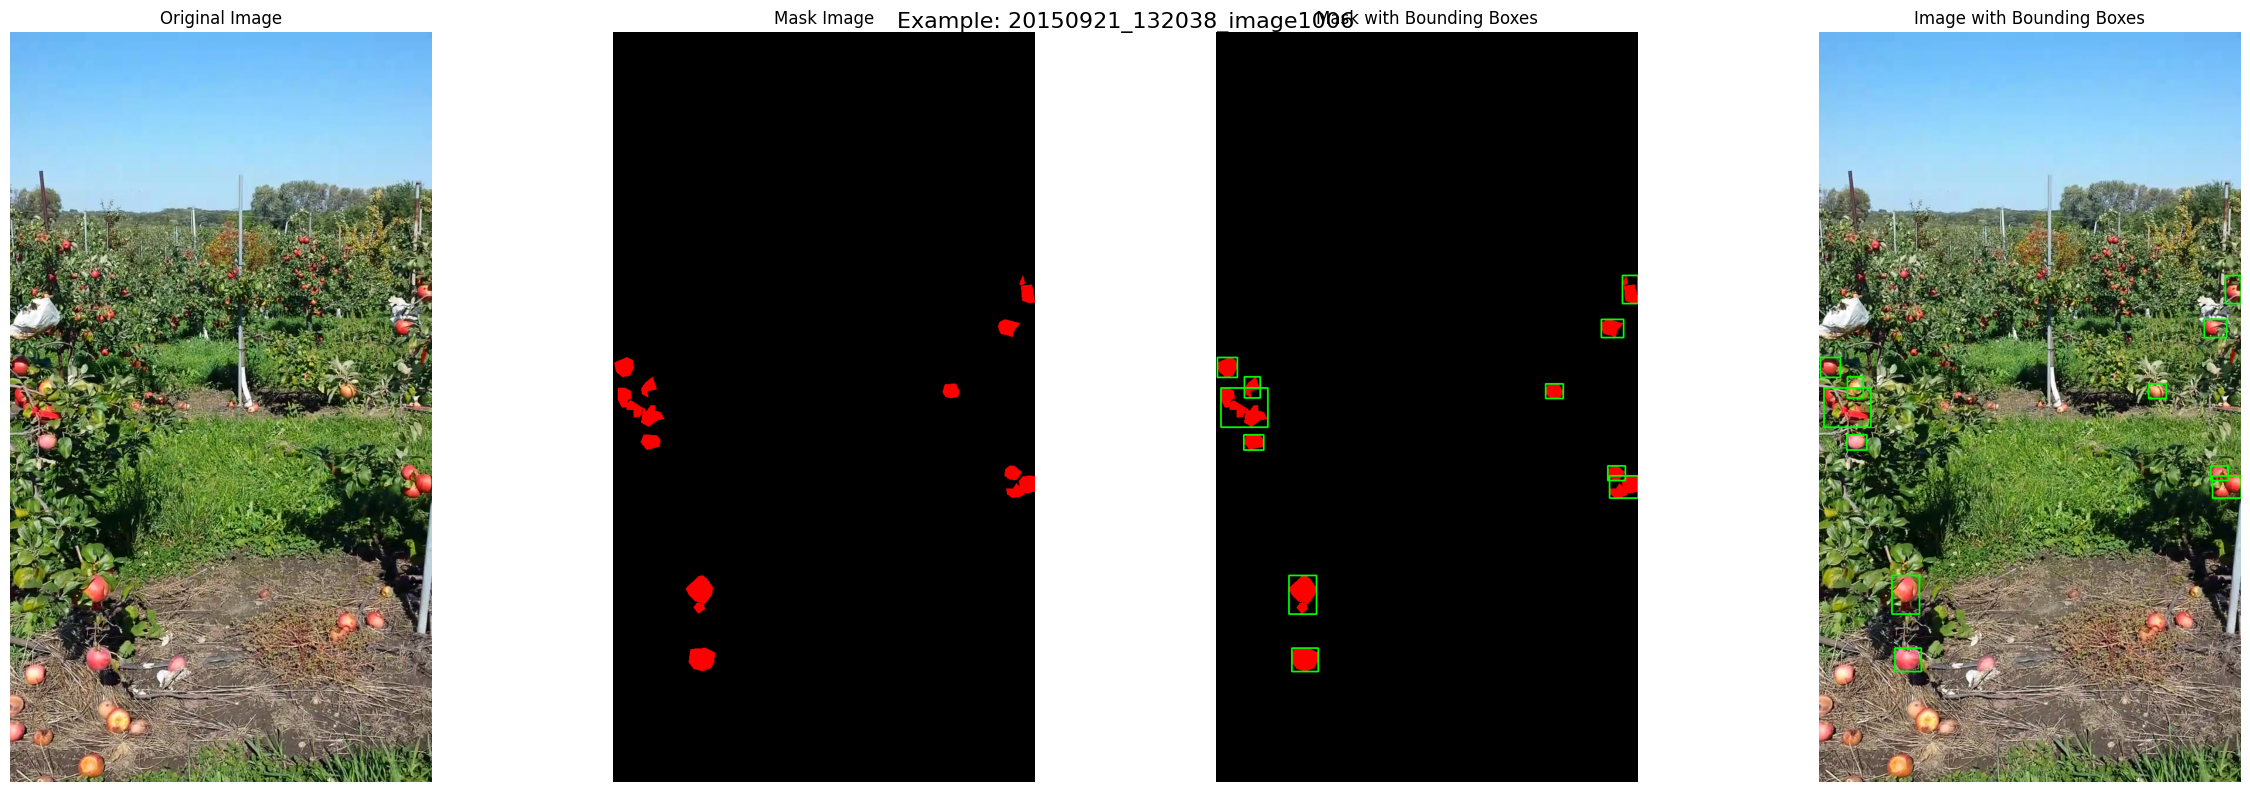

In [3]:

def visualize_comparison(image, mask, boxes, title="Original Image, Mask, Mask with Bounding Boxes, and Image with Bounding Boxes"):
    """ Concatenate and display original image, mask, mask with bounding boxes, and image with bounding boxes in one row with consistent spacing """
    
    if isinstance(image, Image.Image):
        image_np = np.array(image)
    else:
        image_np = image.copy()
    
    if isinstance(mask, Image.Image):
        mask_np = np.array(mask)
    else:
        mask_np = mask.copy()
    
    # Create the mask with bounding boxes
    mask_rgb = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)
    mask_rgb[mask_np > 0] = [255, 0, 0]  # Red color for mask
    
    mask_with_boxes = mask_rgb.copy()
    
    # Draw bounding boxes on the mask
    for box in boxes:
        x_min, y_min, x_max, y_max = [int(coord) for coord in box]
        cv2.rectangle(mask_with_boxes, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green bounding boxes
    
    # Draw bounding boxes on the original image
    image_with_boxes = image_np.copy()
    for box in boxes:
        x_min, y_min, x_max, y_max = [int(coord) for coord in box]
        cv2.rectangle(image_with_boxes, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green bounding boxes
    
    # Create a figure with subplots and consistent spacing
    fig, axs = plt.subplots(1, 4, figsize=(25, 8))
    
    # Plot the original image
    axs[0].imshow(image_np)
    axs[0].set_title("Original Image")
    axs[0].axis('off')
    
    # Plot the mask image
    axs[1].imshow(mask_rgb)
    axs[1].set_title("Mask Image")
    axs[1].axis('off')
    
    # Plot the mask with bounding boxes
    axs[2].imshow(mask_with_boxes)
    axs[2].set_title("Mask with Bounding Boxes")
    axs[2].axis('off')
    
    # Plot the original image with bounding boxes
    axs[3].imshow(image_with_boxes)
    axs[3].set_title("Image with Bounding Boxes")
    axs[3].axis('off')
    
    # Adjust spacing between the images
    plt.tight_layout(pad=1.0)  # Increase padding for better spacing
    plt.suptitle(title, fontsize=16)
    plt.show()




def process_and_visualize_examples(dataset, num_examples=5):
    """ Process and visualize examples from the dataset """
    examples = random.sample(dataset, min(len(dataset), num_examples))
    
    for example in examples:
        print(f"Processing example: {example['id']}")
        image = Image.open(example['image_path']).convert('RGB')
        mask = Image.open(example['mask_path'])
        mask_np = np.array(mask)
        boxes = masks_to_boxes(mask_np)
        
        visualize_comparison(image, mask, boxes, f"Example: {example['id']}")
process_and_visualize_examples(dataset, num_examples=5)

### 3.2 Dataset and Model Implementation

In [4]:
import os
import torch
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.resnet import resnet34
from PIL import Image
from skimage import measure
from skimage.measure import regionprops
import cv2
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.resnet import resnet34
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Subset

### Dataset loading

In [5]:


class FruitDetectionDataset(Dataset):
    def __init__(self, dataset, transform=None, augment=True):
        self.dataset = dataset
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        mask = np.array(Image.open(item["mask_path"]))

        # Extract bounding boxes
        boxes = masks_to_boxes(mask)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.ones((len(boxes),), dtype=torch.int64)
        }
        if self.augment:
            image, target = self.apply_augmentation(image, target)

        if self.transform:
            image = self.transform(image)
        
        return image, target

    def apply_augmentation(self, image, target):
        image_tensor = F.to_tensor(image)
        # Random horizontal flip with 50% probability
        if torch.rand(1).item() > 0.5:
            image = TF.hflip(image)
            target["boxes"][:, [0, 2]] = image.width - target["boxes"][:, [2, 0]]

        # Color Jittering
        if random.random() > 0.5:
            brightness = random.uniform(0.8, 1.2)
            contrast = random.uniform(0.8, 1.2)
            saturation = random.uniform(0.8, 1.2)
            hue = random.uniform(-0.1, 0.1)
            image_tensor = F.adjust_brightness(image_tensor, brightness)
            image_tensor = F.adjust_contrast(image_tensor, contrast)
            image_tensor = F.adjust_saturation(image_tensor, saturation)
            image_tensor = F.adjust_hue(image_tensor, hue)

        return image, target

# Define transformations
transform = T.Compose([T.ToTensor()])

# Load dataset
train_images = load_dataset(train_image_dir,train_mask_dir)
train_datasetf = FruitDetectionDataset(train_images, transform=transform)

# Dataset splitting (80% train, 20% validation)
train_size = int(0.8 * len(train_datasetf))
val_size = len(train_datasetf) - train_size
train_indices = list(range(train_size))
val_indices = list(range(train_size, len(train_datasetf)))

# Use Subset to create the train and validation datasets
train_dataset = Subset(train_datasetf, train_indices)
val_dataset = Subset(train_datasetf, val_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda batch: tuple(zip(*batch)))

# Fetch the first batch from the validation loader
for images, targets in val_loader:
    print("First image shape:", images[0].shape)
    print("First target:", targets[0])
    break  # Break after the first batch to only print the first item


Loaded 670 image-mask pairs
First image shape: torch.Size([3, 1280, 720])
First target: {'boxes': tensor([[4.9000e+01, 8.5000e+01, 8.9000e+01, 1.2700e+02],
        [6.9800e+02, 1.3500e+02, 7.2000e+02, 1.8300e+02],
        [7.0700e+02, 2.1400e+02, 7.1700e+02, 2.3400e+02],
        [1.0700e+02, 2.2100e+02, 1.5800e+02, 2.6500e+02],
        [5.6400e+02, 2.3200e+02, 5.9400e+02, 2.6400e+02],
        [1.8000e+02, 2.8600e+02, 2.1300e+02, 3.2000e+02],
        [5.2500e+02, 3.2000e+02, 5.7800e+02, 3.6000e+02],
        [5.9000e+01, 3.3000e+02, 1.2200e+02, 3.7300e+02],
        [3.4000e+01, 3.3300e+02, 5.1000e+01, 3.5300e+02],
        [1.1200e+02, 3.4200e+02, 1.9500e+02, 4.2000e+02],
        [5.9000e+01, 4.1800e+02, 9.4000e+01, 4.4700e+02],
        [1.7700e+02, 4.4100e+02, 2.1200e+02, 4.8000e+02],
        [1.3500e+02, 4.6500e+02, 1.6200e+02, 4.9900e+02],
        [1.5900e+02, 5.3200e+02, 1.8700e+02, 5.7500e+02],
        [1.1900e+02, 5.4500e+02, 1.4400e+02, 5.7200e+02],
        [2.3400e+02, 5.5200e+02,

### Model Implementation

In [6]:

# Function to create Faster R-CNN with ResNet-34 backbone
def create_faster_rcnn():
    # Load pre-trained ResNet-34 and remove fully connected layers
    backbone = resnet34(pretrained=True)
    backbone = torch.nn.Sequential(*list(backbone.children())[:-2])  # Remove last FC layer
    backbone.out_channels = 512  # ResNet-34 feature maps output 512 channels

    # Define custom anchor sizes and aspect ratios for fruit detection
    anchor_sizes = ((16, 32, 64, 128, 256),)  # Multi-scale anchors
    aspect_ratios = ((0.5, 1.0, 2.0),)  # Standard aspect ratios

    # Create Anchor Generator
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)

    # Create Faster R-CNN model
    model = FasterRCNN(
        backbone,
        num_classes=2,  # Background + Fruit class
        rpn_anchor_generator=anchor_generator
    )

    return model

In [7]:
# Instantiate model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = create_faster_rcnn().to(device)


def load_model(model, save_path):
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
        model.eval()  # Set the model to evaluation mode
        print(f"Model weights loaded from {save_path}")
    else:
        print("No pre-trained model found, starting training from scratch.")
model_save_path = 'fruit_q2.pth'
# Load model weights if they exist before training
load_model(model, model_save_path)
def save_model(model, save_path):
    torch.save(model.state_dict(), save_path)
    print(f"Model weights saved to {save_path}")

# Define optimizer and learning rate scheduler
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=1)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())  # Sum all losses
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    lr_scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")
    save_model(model, model_save_path)

print("Model training complete")


/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model weights loaded from fruit_q2.pth
Epoch 1/5, Loss: 13.0196
Model weights saved to fruit_q2.pth
Epoch 2/5, Loss: 10.1044
Model weights saved to fruit_q2.pth
Epoch 3/5, Loss: 9.9648
Model weights saved to fruit_q2.pth
Epoch 4/5, Loss: 9.8592
Model weights saved to fruit_q2.pth
Epoch 5/5, Loss: 9.5346
Model weights saved to fruit_q2.pth
Model training complete


## 3.3 Training and Detection Analysis

### 1. Detection Pipeline Analysis

#### Justification of Anchor Box Configurations
- **Anchor Sizes (16, 32, 64, 128, 256):** 
  - Ensures effective detection of both small and large fruits at varying distances from the camera.
  - Small sizes capture small fruits (e.g., apples), and larger sizes capture larger fruits (e.g., watermelons).
  
- **Aspect Ratios (0.5, 1.0, 2.0):** 
  - 0.5 for elongated, 1.0 for round, and 2.0 for oval shapes.
  - Helps the model generalize across different fruit shapes (e.g., oranges vs bananas).

#### Role of Non-Maximum Suppression (NMS)
- **Purpose:** Removes redundant boxes by keeping only the highest-confidence box when there is significant overlap.
- **Effect on Fruit Detection:** Reduces false positives by ensuring only one detection per fruit, especially when fruits are close together.

#### Strategies for Handling Overlapping Fruits
- **IoU-based Filtering:** 
  - **Thresholding:** The IoU threshold controls the level of overlap allowed. A threshold of 0.5 or higher ensures that only significantly distinct boxes are retained. Boxes with more than 50% overlap are suppressed.
  - **Example:** This ensures that only one box remains for fruits that are highly clustered or partially occluded.
  
- **Instance Segmentation (Mask R-CNN):** 
  - **Better Handling of Overlaps:** Mask R-CNN generates a **pixel-wise mask** for each detected object, helping to separate fruits that are physically touching or overlapping.
  - **Example:** In a cluster of oranges, Mask R-CNN can distinguish between individual fruits even when they touch or overlap, unlike traditional bounding box methods.

- **Higher-Resolution Images:** 
  - **Improved Detection of Small or Occluded Fruits:** Higher resolution helps detect fine details, especially in dense clusters of fruits.
  - **Example:** In low-resolution images, overlapping fruits may appear as one large object. High resolution allows better separation, capturing more individual fruit instances.

- **Anchor Box Configuration Adjustment for Overlaps:**
  - **Fine-tuning Anchor Sizes & Ratios:** Adjusting anchor boxes to better match the expected scale and shape of overlapping fruits helps the model handle dense areas more effectively.
  - **Example:** If a cluster of small fruits is often missed, decreasing the anchor size and using smaller aspect ratios may improve performance.

#### Impact of IoU Thresholds on Detection Performance
- **Low IoU (0.3):** 
  - **Higher Recall:** More boxes are kept, including those that have significant overlap with others.
  - **Higher False Positives:** Some redundant or overlapping boxes might remain, leading to detections that don't correspond to distinct objects.
  
- **Moderate IoU (0.5):** 
  - **Balanced Precision & Recall:** A moderate IoU threshold provides a good compromise between capturing most fruits and reducing redundant boxes.
  - **Better Object Separation:** Helps in scenarios where fruits are moderately close but not fully overlapping.
  
- **High IoU (0.7):** 
  - **Higher Precision:** Reduces false positives by removing boxes with significant overlap.
  - **Lower Recall:** May miss some fruits that are near each other or overlapping slightly, reducing detection of smaller or occluded fruits.

---

### 2. Strategies for Improving Detection

#### Data Augmentation Techniques
- **Common Techniques:** 
  - **Rotation:** Helps the model recognize fruits from different angles and orientations.
  - **Scaling:** Simulates fruits at varying distances from the camera by adjusting image size.
  - **Flipping:** Increases dataset diversity by simulating different camera perspectives (left-right).
  - **Color Jittering:** Helps the model generalize under different lighting conditions (e.g., brightness, contrast).
  
- **Augmentation Impact:**
  - Increases **model robustness**, especially when fruits appear in various environments or under different lighting conditions.
  - Helps the model learn to detect fruits that are rotated, occluded, or appear in different scales.

---

#### Experimenting with Confidence Thresholds

- **Effect of Lower Confidence Thresholds:**
  - **Higher Recall:** More boxes are kept, as the model is more lenient about what is considered a valid detection.
  - **More False Positives:** Boxes with lower confidence may be inaccurate, leading to redundant detections.
  - **Example:** A confidence threshold of 0.3 would allow more detections, including less confident ones, which may result in detecting partial or incorrect fruits.
  
- **Effect of Higher Confidence Thresholds:**
  - **Higher Precision:** Only boxes with high confidence are kept, reducing false positives.
  - **Lower Recall:** Some true positives (fruits with lower confidence) may be discarded, leading to missed detections.
  - **Example:** A confidence threshold of 0.7 would retain only the most confident predictions, which may miss smaller fruits or fruits in cluttered environments.

- **Dynamic Thresholding:**
  - Instead of a fixed threshold, dynamically adjusting the threshold based on the **object's context** (e.g., distance from camera, occlusion level) could improve performance.
  - **Example:** When detecting fruits in a clustered area, a lower threshold may help capture more fruits, while in more isolated scenarios, a higher threshold might reduce false positives.

- **Trade-off Analysis:**
  - **Lower threshold**: More detections, but many of them are incorrect or redundant.
  - **Higher threshold**: More accurate detections but fewer in total, risking missed detections.
  - Finding an optimal threshold involves a **trade-off** between precision and recall, which can be fine-tuned for the specific application.


---

#### Impact of Image Resolution on Detection Accuracy
- **Low Resolution:**
  - **Pros:** Faster processing, reduced memory usage.
  - **Cons:** Difficulty detecting small fruits, less distinct boundaries between overlapping objects.
  - **Use Case:** Useful for real-time applications where speed is more critical than detection accuracy.
  
- **High Resolution:**
  - **Pros:** Higher accuracy, especially for detecting smaller or occluded fruits.
  - **Cons:** Increased computational cost (slower processing, higher memory usage).
  - **Use Case:** Ideal for high-quality image analysis, where detection precision is essential.

- **Resolution Trade-off:** 
  - **Higher resolution** improves detection, but may lead to **slower inference times**. It’s crucial to balance resolution based on the task’s time and computational constraints.
  
---

### 3.4 Analysis and Evaluation

In [8]:
import torch
import numpy as np

# Helper function to calculate Intersection over Union (IoU)
def compute_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2
    
    # Calculate intersection area
    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    
    # Calculate union area
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)
    
    union_area = box1_area + box2_area - inter_area
    
    # IoU = intersection / union
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

# Helper function to calculate precision and recall for each class
def calculate_precision_recall(pred_boxes, true_boxes, pred_scores=None, iou_threshold=0.5):
    # For single class detection, we just need boxes (and optionally scores for sorting)
    
    # Sort predictions by confidence score if available
    if pred_scores is not None:
        sort_idx = np.argsort(-pred_scores)
        pred_boxes = pred_boxes[sort_idx]
    
    true_positive = 0
    false_positive = 0
    
    # Create a copy of true_boxes to mark matched ones
    matched = [False] * len(true_boxes)
    
    # Iterate over each predicted box
    for pred_box in pred_boxes:
        best_iou = 0
        best_match = -1
        
        # Iterate over each ground truth box to find the best match
        for j, true_box in enumerate(true_boxes):
            if matched[j]:
                continue  # Skip already matched ground truth boxes
                
            iou = compute_iou(pred_box, true_box)
            if iou > best_iou and iou >= iou_threshold:
                best_iou = iou
                best_match = j
        
        if best_match >= 0:
            true_positive += 1
            matched[best_match] = True  # Mark as matched
        else:
            false_positive += 1
    
    # Count false negatives (unmatched ground truth boxes)
    false_negative = sum(1 for m in matched if not m)
    
    # Calculate precision and recall
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    
    return precision, recall

# Helper function to compute Average Precision (AP) using the 11-point interpolation
def compute_average_precision(precisions, recalls):
    # Ensure inputs are numpy arrays
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    
    # Standard 11 points for AP calculation
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    
    return ap

def evaluate_model(val_loader, model, device, iou_thresholds=[0.5, 0.75, 0.85]):
    model.eval()  # Set the model to evaluation mode
    
    all_pred_boxes = []
    all_pred_scores = []
    all_true_boxes = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            # Move data to the appropriate device
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Get outputs from the model
            outputs = model(images)
            
            for i in range(len(outputs)):
                # Get predictions for fruits (assuming class_id=1 for fruits)
                pred_boxes = outputs[i]['boxes'].cpu().numpy()
                pred_scores = outputs[i]['scores'].cpu().numpy()
                pred_labels = outputs[i]['labels'].cpu().numpy()
                
                # Get ground truth boxes for fruits
                true_boxes = targets[i]['boxes'].cpu().numpy()
                true_labels = targets[i]['labels'].cpu().numpy()
                
                # Filter only the fruit class (assuming class_id=1)
                fruit_class_id = 1  # Change this if your fruit class has a different ID
                
                # If you have a single class model, you might skip filtering by class
                # Or filter by the specific class ID for fruits
                pred_idx = pred_labels == fruit_class_id
                true_idx = true_labels == fruit_class_id
                
                # Collect predictions and ground truth
                all_pred_boxes.append(pred_boxes[pred_idx])
                all_pred_scores.append(pred_scores[pred_idx])
                all_true_boxes.append(true_boxes[true_idx])
    
    # Concatenate all batches (if not empty)
    if all_pred_boxes and all(len(boxes) > 0 for boxes in all_pred_boxes):
        all_pred_boxes = np.concatenate(all_pred_boxes, axis=0)
        all_pred_scores = np.concatenate(all_pred_scores, axis=0)
    else:
        all_pred_boxes = np.array([])
        all_pred_scores = np.array([])
    
    if all_true_boxes and all(len(boxes) > 0 for boxes in all_true_boxes):
        all_true_boxes = np.concatenate(all_true_boxes, axis=0)
    else:
        all_true_boxes = np.array([])
    
    # Calculate precision-recall at different IoU thresholds
    precisions = []
    recalls = []
    
    for iou_threshold in iou_thresholds:
        if len(all_pred_boxes) > 0 and len(all_true_boxes) > 0:
            precision, recall = calculate_precision_recall(
                all_pred_boxes, all_true_boxes, all_pred_scores, iou_threshold)
        else:
            precision, recall = 0, 0
            
        precisions.append(precision)
        recalls.append(recall)
    
    # Calculate mAP
    mAP = sum(precisions) / len(precisions)  # Simplified mAP calculation across thresholds
    
    # Return evaluation results
    results = {
        'mAP': mAP,
        'precisions': precisions,
        'recalls': recalls,
        'iou_thresholds': iou_thresholds
    }
    
    return results


# Evaluate model
results = evaluate_model(val_loader, model, device)

# Print results
print(f"\nMean Average Precision (mAP): {results['mAP']:.4f}")

print("\nMetrics at different IoU thresholds:")
for i, threshold in enumerate(results['iou_thresholds']):
    precision = results['precisions'][i]
    recall = results['recalls'][i]
    print(f"  IoU = {threshold}: Precision = {precision:.4f}, Recall = {recall:.4f}")
    



Mean Average Precision (mAP): 0.2167

Metrics at different IoU thresholds:
  IoU = 0.5: Precision = 0.4308, Recall = 0.6815
  IoU = 0.75: Precision = 0.1638, Recall = 0.2591
  IoU = 0.85: Precision = 0.0554, Recall = 0.0877



Evaluating with IoU threshold: 0.1
Mean Average Precision (mAP@0.1): 0.6264
Fruit Class AP: 0.6264

False Positive and False Negative Analysis:
Class 1: False Positives = 1835.0, False Negatives = 913.0

Evaluating with IoU threshold: 0.3
Mean Average Precision (mAP@0.3): 0.5765
Fruit Class AP: 0.5765

False Positive and False Negative Analysis:
Class 1: False Positives = 2005.0, False Negatives = 1054.0

Evaluating with IoU threshold: 0.4
Mean Average Precision (mAP@0.4): 0.4985
Fruit Class AP: 0.4985

False Positive and False Negative Analysis:
Class 1: False Positives = 2201.0, False Negatives = 1296.0

Evaluating with IoU threshold: 0.5
Mean Average Precision (mAP@0.5): 0.4184
Fruit Class AP: 0.4184

False Positive and False Negative Analysis:
Class 1: False Positives = 2465.0, False Negatives = 1580.0


/tmp/ipykernel_1120856/1803878727.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(iou_thresholds))


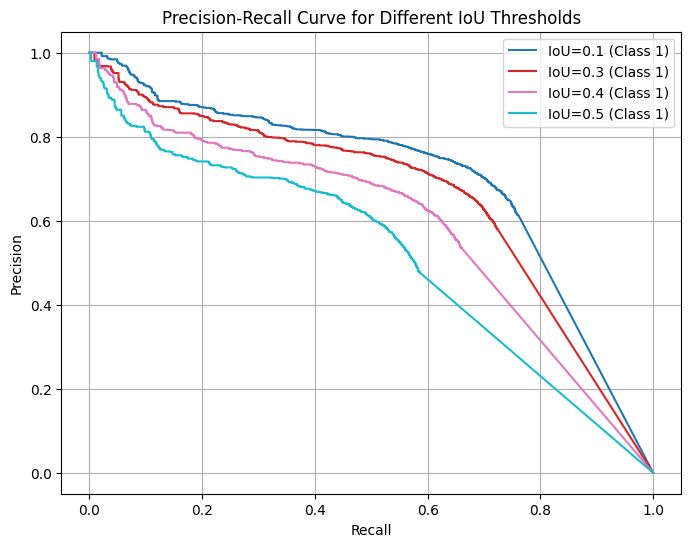

In [11]:
import torch
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# Custom function to compute Intersection over Union (IoU) between two bounding boxes
def calculate_iou(box_a, box_b):
    # Extract coordinates from the two boxes
    x1, y1, x2, y2 = box_a
    x1_gt, y1_gt, x2_gt, y2_gt = box_b
    
    # Calculate the coordinates of the intersection
    x_inter1 = max(x1, x1_gt)
    y_inter1 = max(y1, y1_gt)
    x_inter2 = min(x2, x2_gt)
    y_inter2 = min(y2, y2_gt)
    
    # Area of intersection
    intersection_area = max(0, x_inter2 - x_inter1) * max(0, y_inter2 - y_inter1)
    
    # Area of each box
    area_box_a = (x2 - x1) * (y2 - y1)
    area_box_b = (x2_gt - x1_gt) * (y2_gt - y1_gt)
    
    # Union area
    union_area = area_box_a + area_box_b - intersection_area
    
    return intersection_area / union_area if union_area > 0 else 0

# Custom method for calculating mean average precision (mAP) over validation data
def evaluate_mean_average_precision(model, data_loader, iou_thresh=0.5, score_thresh=0.5):
    """
    This function evaluates the performance of a given object detection model
    using mAP metric, considering different IoU thresholds and score thresholds.
    
    Parameters:
    - model: The object detection model to evaluate.
    - data_loader: Dataloader for validation images and annotations.
    - iou_thresh: Intersection over Union threshold for evaluating predictions.
    - score_thresh: Minimum score to keep a prediction as valid.
    """
    model.eval()  # Switch model to evaluation mode
    all_preds = defaultdict(list)
    all_gt = defaultdict(list)

    # Process each image and its corresponding ground-truth in the validation set
    for batch_idx, (images, targets) in enumerate(data_loader):
        print(f"Processing image {batch_idx+1}/{len(data_loader)}", end="\r")
        
        # Send images and targets to the correct device (GPU/CPU)
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]

        # Get predictions from the model
        with torch.no_grad():
            outputs = model(images)

        # Process each output per image
        for idx in range(len(outputs)):
            # Extract bounding boxes, labels, and scores
            pred_boxes = outputs[idx]['boxes'].cpu().numpy()
            pred_labels = outputs[idx]['labels'].cpu().numpy()
            pred_scores = outputs[idx]['scores'].cpu().numpy()
            
            # Filter out predictions with low confidence
            mask = pred_scores >= score_thresh
            pred_boxes, pred_labels, pred_scores = pred_boxes[mask], pred_labels[mask], pred_scores[mask]

            # Collect predictions for the class of interest (e.g., fruits)
            for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
                if label == 0:  # Assuming '0' is the background class
                    continue
                all_preds[int(label)].append((batch_idx, score, box.tolist()))

            # Collect ground truth boxes
            true_boxes = targets[idx]['boxes'].cpu().numpy()
            true_labels = targets[idx]['labels'].cpu().numpy()
            
            for box, label in zip(true_boxes, true_labels):
                if label == 0:  # Skip background class
                    continue
                all_gt[int(label)].append((batch_idx, box))

    # Now, compute average precision (AP) per class using the IoU and score thresholds
    ap_per_class = {}
    precision_recall_data = {}
    false_positives, false_negatives = {}, {}

    # Iterate through each class and calculate AP, precision, recall, FP, and FN
    for class_id in all_gt:
        if class_id not in all_preds:
            ap_per_class[class_id] = 0  # No predictions for this class
            continue

        # Sort predictions by score in descending order
        predictions = sorted(all_preds[class_id], key=lambda x: x[1], reverse=True)
        tp = np.zeros(len(predictions))
        fp = np.zeros(len(predictions))
        num_gt = len(all_gt[class_id])

        gt_matched = {}  # Keep track of matched ground truth boxes
        for img_id, gt_box in all_gt[class_id]:
            gt_matched[(img_id, tuple(gt_box))] = False

        # Evaluate each prediction
        for i, (img_id, _, pred_box) in enumerate(predictions):
            img_gts = [(gt_img_id, gt_box) for gt_img_id, gt_box in all_gt[class_id] if gt_img_id == img_id]

            if not img_gts:
                fp[i] = 1
                continue

            max_iou = -np.inf
            matched_gt = None
            for gt_img_id, gt_box in img_gts:
                iou = calculate_iou(pred_box, gt_box)
                if iou > max_iou:
                    max_iou, matched_gt = iou, (gt_img_id, tuple(gt_box))

            if max_iou >= iou_thresh and not gt_matched.get(matched_gt, True):
                tp[i] = 1
                gt_matched[matched_gt] = True
            else:
                fp[i] = 1

        # Compute False Negatives (FN) and False Positives (FP)
        fn = num_gt - sum(tp)
        false_positives[class_id] = sum(fp)
        false_negatives[class_id] = fn

        # Compute precision and recall for this class
        cumsum_tp, cumsum_fp = np.cumsum(tp), np.cumsum(fp)
        precision = cumsum_tp / (cumsum_tp + cumsum_fp)
        recall = cumsum_tp / num_gt

        precision = np.insert(precision, 0, 1)
        recall = np.insert(recall, 0, 0)
        precision = np.append(precision, 0)
        recall = np.append(recall, 1)

        # Ensure precision is non-decreasing
        for i in range(len(precision) - 2, -1, -1):
            precision[i] = max(precision[i], precision[i + 1])

        # Calculate Average Precision (AP) using the area under the precision-recall curve
        ap = np.sum((recall[1:] - recall[:-1]) * precision[1:])
        ap_per_class[class_id] = ap
        precision_recall_data[class_id] = (recall, precision)

    # Calculate mean average precision (mAP) across all classes
    mean_ap = np.mean(list(ap_per_class.values()))
    return mean_ap, ap_per_class, precision_recall_data, false_positives, false_negatives



# Analyzing false positives and false negatives
def analyze_false_predictions(fp, fn):
    print("\nFalse Positive and False Negative Analysis:")
    for class_id in fp:
        print(f"Class {class_id}: False Positives = {fp[class_id]}, False Negatives = {fn[class_id]}")

# Example of running the evaluation with custom threshold
def run_evaluation(model, val_loader, device):
    iou_thresholds = [0.1,0.3,0.4, 0.5]

    pr_data_by_iou = {}
    for iou_thresh in iou_thresholds:
        print(f"\nEvaluating with IoU threshold: {iou_thresh}")
        map_score, ap_by_class, pr_data, fp, fn = evaluate_mean_average_precision(model, val_loader, iou_thresh=iou_thresh)

        print(f"Mean Average Precision (mAP@{iou_thresh}): {map_score:.4f}")
        print(f"Fruit Class AP: {ap_by_class.get(1, 0):.4f}")

        # Store the precision-recall data for this IoU threshold
        pr_data_by_iou[iou_thresh] = pr_data
        
        # Print false positive and negative analysis
        analyze_false_predictions(fp, fn)
    
    # After evaluating for all IoU thresholds, plot all precision-recall curves
    plt.figure(figsize=(8, 6))
    
    # Define a color map for the curves
    colors = plt.cm.get_cmap('tab10', len(iou_thresholds))
    
    # Plot precision-recall curves for each IoU threshold
    for idx, (iou_thresh, pr_data) in enumerate(pr_data_by_iou.items()):
        for class_id, (recall, precision) in pr_data.items():
            plt.plot(recall, precision, label=f'IoU={iou_thresh} (Class {class_id})', color=colors(idx))

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Different IoU Thresholds')
    plt.legend()
    plt.grid(True)
    plt.show()


# Assuming val_loader and model are defined
run_evaluation(model, val_loader, device)


## Fruit Detection Performance Analysis

### 1. Impact of Occlusion on Detection Accuracy
- **Occlusion** occurs when fruits are partially hidden by others, causing **false positives** or **false negatives**.
- **Challenges**:
  - Missing or incomplete bounding boxes for occluded fruits.
  - Non-distinction between multiple fruits in a single bounding box.
- **Strategies**:
  - Augment the dataset with occluded samples.
  - Use **Mask R-CNN** for instance segmentation, which handles occlusion better than Faster R-CNN.

### 2. Effect of Fruit Color Variations and Lighting Conditions
- **Lighting variations** and **color differences** can reduce detection accuracy, especially in poor lighting or with high/low contrast conditions.
- **Challenges**:
  - Underexposed/overexposed images may lead to poor feature extraction.
  - Fruits with similar colors to the background or other fruits are harder to detect.
- **Strategies**:
  - Use **Color Jittering** data augmentation to simulate lighting/color variations.
  - Preprocess images with **white-balance correction** to standardize lighting conditions.

### 3. Performance on Densely Clustered Fruits vs Isolated Fruits
- **Densely clustered fruits** are harder to detect due to occlusion and overlaps, leading to incorrect bounding boxes.
- **Challenges**:
  - **False positives** and **false negatives** in crowded scenes.
  - Difficulty distinguishing individual objects.
- **Strategies**:
  - **Anchor Box Adjustment** for better handling of overlapping fruits.
  - Consider **Instance Segmentation** to separate overlapping fruits.

### 4. Model’s Behavior with Fruits at Different Scales
- Fruits appear at **different scales** (small, medium, large), posing a challenge for detection.
- **Challenges**:
  - Small fruits are difficult to detect due to fewer pixels.
  - Large fruits may overlap with others, affecting the quality of detection.
- **Strategies**:
  - Configure **Anchor Boxes** to match fruit sizes.
  - Implement **Multi-Scale Training** for better generalization across scales.
  - Use **Scale Augmentation** to improve performance on fruits of varying sizes.


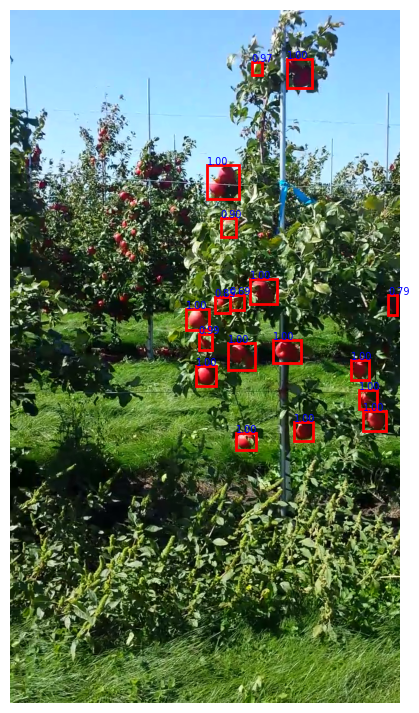

In [10]:

from matplotlib import patches
# Assuming 'model' is a pre-trained Faster R-CNN model, and 'train_loader' is your data loader
model.eval()

# Load a single batch of images and targets
for idx, (images, targets) in enumerate(val_loader):
    if idx != 25:
        continue
    images = [img.to(device) for img in images]
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
    # Get outputs from the model
    with torch.no_grad():
        outputs = model(images)

    
    # Get the first image's output (assuming batch size of 1 for visualization)
    boxes = outputs[0]['boxes'].cpu().numpy()
    scores = outputs[0]['scores'].cpu().numpy()
    labels = outputs[0]['labels'].cpu().numpy()
    
    # Filter boxes with scores greater than 0.5
    high_score_indices = scores > 0.5
    boxes = boxes[high_score_indices]
    labels = labels[high_score_indices]
    scores = scores[high_score_indices]
    
    # Convert the tensor to numpy for visualization
    image = images[0].cpu().permute(1, 2, 0).numpy()
    
    # Normalize the image back to [0, 1] range (if required)
    image = np.clip(image, 0, 1)

    # Plotting the image
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image)
    
    # Draw the bounding boxes
    for box, score, label in zip(boxes, scores, labels):
        x_min, y_min, x_max, y_max = box
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_max - x_min, 
            y_max - y_min, 
            linewidth=2, 
            edgecolor='r', 
            facecolor='none'
        )
        ax.add_patch(rect)
        
        # Display score
        ax.text(
            x_min, y_min, 
            f'{score:.2f}', 
            color='blue', 
            fontsize=7, 
        )
    plt.axis('off')
    plt.show()
 